In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from itertools import combinations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern
from sklearn.preprocessing import StandardScaler

# --------------------------
# 1. 数据加载与预处理
# --------------------------
def load_data():
    """加载训练数据"""
    try:
        data = pd.read_csv('E:/Desktop/Yield2.csv')
        new_data = pd.read_csv('E:/Desktop/Yield3.csv')
        combined = pd.concat([data, new_data], axis=0)
        required_cols = ['LasR','ER','PR','XlnR','DHBR','RpaR','lacI','CinR','Yield']
        return combined[required_cols].drop_duplicates()
    except Exception as e:
        print(f"数据加载失败: {str(e)}")
        raise

# --------------------------
# 2. 模型训练
# --------------------------
class YieldPredictor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.gp = None
        self.vars = ['LasR','ER','PR','XlnR','DHBR','RpaR','lacI','CinR']
        self.bounds = np.array([
            [0.06,27.2], [0.04,14.1], [0.296,23.56], [0.161,40.75],
            [0.238,11.9], [0.176,31.6], [0.082,6.02], [0.484,13.26]
        ])
        self.median_values = None
        
    def train(self, data):
        """训练模型并计算基准值"""
        X = data[self.vars].values
        y = data['Yield'].values
        
        self.scaler.fit(X)
        X_scaled = self.scaler.transform(X)
        
        kernel = C(1.0, (1e-5, 1e6)) * Matern(
            length_scale=[1.0]*len(self.vars),
            length_scale_bounds=(1e-6, 1e6),
            nu=1.5
        )
        
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=50,
            alpha=0.1,
            normalize_y=True
        )
        self.gp.fit(X_scaled, y)
        
        # 计算各变量中位数作为基准
        self.median_values = data[self.vars].median().values
        return self

# --------------------------
# 3. 热图可视化系统
# --------------------------
class OptimizationVisualizer:
    def __init__(self, predictor):
        self.predictor = predictor
        self.output_dir = os.path.expanduser("E:/Desktop/Optimization_Results")
        os.makedirs(self.output_dir, exist_ok=True)
        
        # 可视化配置
        self.style = {
            'first': {'color': '#FF6B6B', 'marker': 'o', 'size': 60, 'label': 'Round 1'},
            'second': {'color': '#4ECDC4', 'marker': 's', 'size': 80, 'label': 'Round 2'},
            'cmap': 'viridis',
            'contour_levels': 20,
            'peak_contour': {'colors': 'white', 'linewidths': 1, 'linestyles': 'dashed'}
        }
        
    def visualize_optimization(self, first_points, second_points):
        """生成所有变量组合的优化验证图"""
        for var1, var2 in combinations(self.predictor.vars, 2):
            try:
                # 生成预测网格
                grid_x, grid_y, pred_grid = self._create_prediction_grid(var1, var2)
                predictions = self.predictor.gp.predict(pred_grid).reshape(grid_x.shape)
                
                # 创建画布
                plt.figure(figsize=(10, 8), dpi=150)
                
                # 绘制热图
                contour = plt.contourf(grid_x, grid_y, predictions, 
                                      levels=self.style['contour_levels'], 
                                      cmap=self.style['cmap'])
                plt.colorbar(contour, label='Predicted Yield', shrink=0.8)
                
                # 标记预测峰值区域
                peak_level = np.percentile(predictions, 95)
                plt.contour(grid_x, grid_y, predictions, 
                           levels=[peak_level], 
                           **self.style['peak_contour'])
                
                # 绘制实验点
                self._plot_points(var1, var2, first_points, 'first')
                self._plot_points(var1, var2, second_points, 'second')
                
                # 图表装饰
                plt.title(f"Optimization Progress: {var1} vs {var2}")
                plt.xlabel(var1)
                plt.ylabel(var2)
                plt.legend()
                
                # 保存结果
                plt.savefig(os.path.join(self.output_dir, f"{var1}_vs_{var2}.png"),
                           bbox_inches='tight', pad_inches=0.2)
                plt.close()
                
            except Exception as e:
                print(f"生成 {var1} vs {var2} 图表失败: {str(e)}")
    
    def _create_prediction_grid(self, var1, var2, res=100):
        """创建预测网格"""
        idx1 = self.predictor.vars.index(var1)
        idx2 = self.predictor.vars.index(var2)
        
        # 生成二维网格
        x = np.linspace(*self.predictor.bounds[idx1], res)
        y = np.linspace(*self.predictor.bounds[idx2], res)
        grid_x, grid_y = np.meshgrid(x, y)
        
        # 构建完整8D输入（其他变量取中位数）
        full_grid = np.tile(self.predictor.median_values, (grid_x.size, 1))
        full_grid[:, idx1] = grid_x.ravel()
        full_grid[:, idx2] = grid_y.ravel()
        
        return grid_x, grid_y, self.predictor.scaler.transform(full_grid)
    
    def _plot_points(self, var1, var2, points, round_type):
        """绘制实验点（带完整特征处理）"""
        style = self.style[round_type]
        idx1 = self.predictor.vars.index(var1)
        idx2 = self.predictor.vars.index(var2)
        
        # 构建完整特征矩阵
        full_points = np.tile(self.predictor.median_values, (len(points), 1))
        full_points[:, idx1] = points[:, idx1]
        full_points[:, idx2] = points[:, idx2]
        
        # 获取预测值用于颜色映射
        scaled = self.predictor.scaler.transform(full_points)
        pred_yield = self.predictor.gp.predict(scaled)
        
        # 绘制点
        plt.scatter(
            points[:, idx1], points[:, idx2],
            c=pred_yield,
            cmap=self.style['cmap'],
            marker=style['marker'],
            edgecolors=style['color'],
            linewidths=1.5,
            s=style['size'],
            label=style['label'],
            zorder=10  # 确保点在顶层
        )

# --------------------------
# 4. 主程序
# --------------------------
if __name__ == "__main__":
    try:
        # 初始化
        predictor = YieldPredictor().train(load_data())
        
        # 加载实验点数据
        def load_exp_points(path):
            df = pd.read_csv(path)
            return df[predictor.vars].values.astype(float)
        
        first_points = load_exp_points('E:/Desktop/n.csv')
        second_points = load_exp_points('E:/Desktop/Yield5.csv')
        
        # 生成可视化结果
        visualizer = OptimizationVisualizer(predictor)
        visualizer.visualize_optimization(first_points, second_points)
        
        print(f"验证完成！结果保存至: {visualizer.output_dir}")
        
    except Exception as e:
        print(f"程序运行失败: {str(e)}")

验证完成！结果保存至: E:/Desktop/Optimization_Results


In [18]:
import pandas as pd

# 读取原始 CSV 文件
df = pd.read_csv("E:/Desktop/round1.csv")

# 过滤：去掉 PR > 23.55838894 的行
filtered_df = df[df["PR"] <= 23.55838894]

# 保存为新文件（可自定义路径）
filtered_df.to_csv("E:/Desktop/round1_filtered.csv", index=False)

# 显示前几行结果确认
print(filtered_df.head())


   No.  Scilv2       LasR  RPU  Scilv6         ER  RPU.1  PailvC         PR  \
0    1       2   3.242927  NaN       3  11.030335    NaN       2  12.436266   
1    2       2   6.587817  NaN       2  11.587507    NaN       2  13.764192   
2    3       3  22.478363  NaN       2  12.904290    NaN       2  13.511608   
3    4       1   0.053489  NaN       2   6.346375    NaN       2  19.051755   
4    5       2   6.964836  NaN       1   0.056460    NaN       2  19.345199   

   RPU.2  ...  MtpanE       RpaR  RPU.5  TcpanD      lacI  RPU.6  CgpanC  \
0    NaN  ...       3  27.091748    NaN       2  1.435832    NaN       1   
1    NaN  ...       3  28.018510    NaN       1 -0.017458    NaN       3   
2    NaN  ...       3  31.954002    NaN       2  0.980809    NaN       2   
3    NaN  ...       1   0.195196    NaN       2  2.160156    NaN       2   
4    NaN  ...       2  17.218659    NaN       2  1.673559    NaN       2   

        CinR  RPU.7   Yield  
0   0.728224    NaN  0.0994  
1  10.08

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe

# 创建保存图片的文件夹
save_dir = 'E:/Desktop/fig_optimalround3'
os.makedirs(save_dir, exist_ok=True)

# 加载训练数据
data1 = pd.read_csv('E:/Desktop/Yield3.csv')
data2 = pd.read_csv('E:/Desktop/round3.csv')
data3 = pd.read_csv('E:/Desktop/Yield5.csv')
data4 = pd.read_csv('E:/Desktop/Yield1.csv')
data5 = pd.read_csv('E:/Desktop/Yield0.csv')
data6 = pd.read_csv('E:/Desktop/Yield2.csv')
combined_data = pd.concat([data1, data2, data3, data4, data5, data6], ignore_index=True)
X = combined_data[['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']].values
X = combined_data[['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']].values
y = combined_data['Yield'].values

# 训练高斯过程回归模型
kernel = C(1.0, (1e-6, 1e6)) * RBF(length_scale=[1.0]*X.shape[1], length_scale_bounds=(1e-6, 1e6))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=1e-3)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
gp.fit(X_scaled, y)

# 加载每轮优化数据
first_round = pd.read_csv('E:/Desktop/Yield0.csv')
second_round = pd.read_csv('E:/Desktop/round2.csv')
third_round = data2[data2['Yield'] > 0.3] 

# 参数名及边界（已更新）
variables = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
bounds = np.array([
    [0.06, 15.2],     # LasR
    [0.04, 14.1],     # ER
    [0.296, 23.56],   # PR
    [0.161, 40.75],   # XlnR
    [0.238, 11.9],    # DHBR
    [0.176, 31.6],    # RpaR
    [0.082, 6.02],    # lacI
    [0.484, 13.26]    # CinR
])
fixed_values = combined_data[variables].mean(axis=0)

# 辅助函数：过滤超出边界的点
def filter_within_bounds(df, var1, var2, bounds, variables):
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    return df[(df[var1] >= bounds[i1][0]) & (df[var1] <= bounds[i1][1]) &
              (df[var2] >= bounds[i2][0]) & (df[var2] <= bounds[i2][1])]

# 遍历所有变量对并绘图
for var1, var2 in combinations(variables, 2):
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    
    # 网格坐标
    x_grid = np.linspace(bounds[i1][0], bounds[i1][1], 50)
    y_grid = np.linspace(bounds[i2][0], bounds[i2][1], 50)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    # 预测点
    grid_samples = np.tile(fixed_values, (xx.size, 1))
    grid_samples[:, i1] = xx.ravel()
    grid_samples[:, i2] = yy.ravel()
    grid_scaled = scaler.transform(grid_samples)
    mu, _ = gp.predict(grid_scaled, return_std=True)

    mu = mu.reshape(xx.shape)

    # 热图
    contour = ax.contourf(xx, yy, mu, levels=20, cmap='viridis')
    plt.colorbar(contour, label='Predicted Yield', shrink=0.8)

    # 过滤每轮数据
    first_valid = filter_within_bounds(first_round, var1, var2, bounds, variables)
    second_valid = filter_within_bounds(second_round, var1, var2, bounds, variables)
    third_valid = filter_within_bounds(third_round, var1, var2, bounds, variables)

    # 散点图
    ax.scatter(first_valid[var1], first_valid[var2],
               c='red', s=80, edgecolor='k', label='Round 1 (n={})'.format(len(first_valid)))
    ax.scatter(second_valid[var1], second_valid[var2],
               c='blue', s=80, marker='s', edgecolor='k', label='Round 2 (n={})'.format(len(second_valid)))
    ax.scatter(third_valid[var1], third_valid[var2],
               c='white', s=80, marker='^', edgecolor='k', label='Round 3 (n={})'.format(len(third_valid)))

    # 均值路径
    first_mean = [first_valid[var1].mean(), first_valid[var2].mean()]
    second_mean = [second_valid[var1].mean(), second_valid[var2].mean()]
    third_mean = [third_valid[var1].mean(), third_valid[var2].mean()]
    
    ax.plot([first_mean[0], second_mean[0], third_mean[0]],
            [first_mean[1], second_mean[1], third_mean[1]],
            'w-', linewidth=2.5, alpha=0.8,
            path_effects=[pe.Stroke(linewidth=3.5, foreground='k'), pe.Normal()])
    
    # 注释优化路径变化
    annotation_text = (
        f"Optimization Progress:\n"
        f"Round1 → Round2: Δ={np.linalg.norm(np.array(second_mean) - np.array(first_mean)):.2f}\n"
        f"Round2 → Round3: Δ={np.linalg.norm(np.array(third_mean) - np.array(second_mean)):.2f}"
    )
    ax.annotate(annotation_text,
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5))

    # 轴标签和标题
    plt.title(f"{var1} vs {var2}")
    plt.xlabel(var1, fontsize=10)
    plt.ylabel(var2, fontsize=10)
    plt.legend()

    # 保存图像
    filename = f"{var1}_vs_{var2}.svg"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

print(f"所有图片已保存至：{save_dir}")

所有图片已保存至：E:/Desktop/fig_optimalround3


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe

# 创建保存图片的文件夹
save_dir = 'E:/Desktop/fig_optimalround4'
os.makedirs(save_dir, exist_ok=True)

# 加载训练数据
data1 = pd.read_csv('E:/Desktop/Yield3.csv')
data2 = pd.read_csv('E:/Desktop/round3.csv')
data3 = pd.read_csv('E:/Desktop/Yield5.csv')
data4 = pd.read_csv('E:/Desktop/Yield1.csv')
data5 = pd.read_csv('E:/Desktop/Yield0.csv')
data6 = pd.read_csv('E:/Desktop/Yield2.csv')
combined_data = pd.concat([data1, data2, data3, data4, data5, data6], ignore_index=True)
X = combined_data[['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']].values
y = combined_data['Yield'].values

# 训练高斯过程回归模型
kernel = C(1.0, (1e-6, 1e6)) * RBF(length_scale=[1.0]*X.shape[1], length_scale_bounds=(1e-6, 1e6))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=1e-3)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
gp.fit(X_scaled, y)

# 加载每轮优化数据
first_round = pd.read_csv('E:/Desktop/Yield0.csv')
second_round = pd.read_csv('E:/Desktop/round2.csv')
third_round = data2[data2['Yield'] > 0.3] 

# 参数名及边界
variables = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
bounds = np.array([
    [0.06, 15.2],     # LasR
    [0.04, 14.1],     # ER
    [0.296, 23.56],   # PR
    [0.161, 40.75],   # XlnR
    [0.238, 11.9],    # DHBR
    [0.176, 31.6],    # RpaR
    [0.082, 6.02],    # lacI
    [0.484, 13.26]    # CinR
])
fixed_values = combined_data[variables].mean(axis=0)

# 辅助函数：过滤超出边界的点
def filter_within_bounds(df, var1, var2, bounds, variables):
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    return df[(df[var1] >= bounds[i1][0]) & (df[var1] <= bounds[i1][1]) &
              (df[var2] >= bounds[i2][0]) & (df[var2] <= bounds[i2][1])]

# 保存所有图中范围内的点（不重复记录）
round1_within = pd.DataFrame()
round2_within = pd.DataFrame()
round3_within = pd.DataFrame()

# 遍历所有变量对并绘图
for var1, var2 in combinations(variables, 2):
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    
    # 网格坐标
    x_grid = np.linspace(bounds[i1][0], bounds[i1][1], 50)
    y_grid = np.linspace(bounds[i2][0], bounds[i2][1], 50)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    # 构造预测点
    grid_samples = np.tile(fixed_values, (xx.size, 1))
    grid_samples[:, i1] = xx.ravel()
    grid_samples[:, i2] = yy.ravel()
    grid_scaled = scaler.transform(grid_samples)
    mu, _ = gp.predict(grid_scaled, return_std=True)
    mu = mu.reshape(xx.shape)

    # 热图
    contour = ax.contourf(xx, yy, mu, levels=20, cmap='viridis')
    plt.colorbar(contour, label='Predicted Yield', shrink=0.8)

    # 过滤每轮数据
    first_valid = filter_within_bounds(first_round, var1, var2, bounds, variables)
    second_valid = filter_within_bounds(second_round, var1, var2, bounds, variables)
    third_valid = filter_within_bounds(third_round, var1, var2, bounds, variables)

    # 收集落在图中范围内的点
    round1_within = pd.concat([round1_within, first_valid])
    round2_within = pd.concat([round2_within, second_valid])
    round3_within = pd.concat([round3_within, third_valid])

    # 散点图
    ax.scatter(first_valid[var1], first_valid[var2],
               c='red', s=80, edgecolor='k', label='Round 1 (n={})'.format(len(first_valid)))
    ax.scatter(second_valid[var1], second_valid[var2],
               c='blue', s=80, marker='s', edgecolor='k', label='Round 2 (n={})'.format(len(second_valid)))
    ax.scatter(third_valid[var1], third_valid[var2],
               c='white', s=80, marker='^', edgecolor='k', label='Round 3 (n={})'.format(len(third_valid)))

    # 均值路径
    first_mean = [first_valid[var1].mean(), first_valid[var2].mean()]
    second_mean = [second_valid[var1].mean(), second_valid[var2].mean()]
    third_mean = [third_valid[var1].mean(), third_valid[var2].mean()]
    
    ax.plot([first_mean[0], second_mean[0], third_mean[0]],
            [first_mean[1], second_mean[1], third_mean[1]],
            'w-', linewidth=2.5, alpha=0.8,
            path_effects=[pe.Stroke(linewidth=3.5, foreground='k'), pe.Normal()])

    # 注释优化路径变化
    annotation_text = (
        f"Optimization Progress:\n"
        f"Round1 → Round2: Δ={np.linalg.norm(np.array(second_mean) - np.array(first_mean)):.2f}\n"
        f"Round2 → Round3: Δ={np.linalg.norm(np.array(third_mean) - np.array(second_mean)):.2f}"
    )
    ax.annotate(annotation_text,
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5))

    # 轴标签和标题
    plt.title(f"{var1} vs {var2}")
    plt.xlabel(var1, fontsize=10)
    plt.ylabel(var2, fontsize=10)
    plt.legend()

    # 保存图像
    filename = f"{var1}_vs_{var2}.svg"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

# 去重并保存三轮图中范围内数据
round1_within = round1_within.drop_duplicates(subset=variables + ['Yield'])
round2_within = round2_within.drop_duplicates(subset=variables + ['Yield'])
round3_within = round3_within.drop_duplicates(subset=variables + ['Yield'])

round1_within.to_csv(os.path.join(save_dir, "Round1_within_bounds.csv"), index=False)
round2_within.to_csv(os.path.join(save_dir, "Round2_within_bounds.csv"), index=False)
round3_within.to_csv(os.path.join(save_dir, "Round3_within_bounds.csv"), index=False)

print(f"所有图片已保存至：{save_dir}")
print("三轮数据中位于图中范围内的点已分别保存为：")
print("  - Round1_within_bounds.csv")
print("  - Round2_within_bounds.csv")
print("  - Round3_within_bounds.csv")


所有图片已保存至：E:/Desktop/fig_optimalround4
三轮数据中位于图中范围内的点已分别保存为：
  - Round1_within_bounds.csv
  - Round2_within_bounds.csv
  - Round3_within_bounds.csv


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe

# 创建保存图片的文件夹
save_dir = 'E:/Desktop/fig_optimalround3'
os.makedirs(save_dir, exist_ok=True)

# 加载训练数据
data1 = pd.read_csv('E:/Desktop/Yield3.csv')
data2 = pd.read_csv('E:/Desktop/round3.csv')
data3 = pd.read_csv('E:/Desktop/Yield5.csv')
data4 = pd.read_csv('E:/Desktop/Yield1.csv')
data5 = pd.read_csv('E:/Desktop/Yield0.csv')
data6 = pd.read_csv('E:/Desktop/Yield2.csv')
combined_data = pd.concat([data1, data2, data3, data4, data5, data6], ignore_index=True)
variables = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
X = combined_data[variables].values
y = combined_data['Yield'].values

# 高斯过程回归训练
kernel = C(1.0, (1e-6, 1e6)) * RBF(length_scale=[1.0]*X.shape[1], length_scale_bounds=(1e-6, 1e6))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=1e-3)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
gp.fit(X_scaled, y)

# 加载三轮原始数据
first_round = pd.read_csv('E:/Desktop/Yield0.csv')
second_round = pd.read_csv('E:/Desktop/round2.csv')
third_round = data2[data2['Yield'] > 0.3]

# 参数边界
bounds = np.array([
    [0.06, 15.2],     # LasR
    [0.04, 14.1],     # ER
    [0.296, 23.56],   # PR
    [0.161, 40.75],   # XlnR
    [0.238, 11.9],    # DHBR
    [0.176, 31.6],    # RpaR
    [0.082, 6.02],    # lacI
    [0.484, 13.26]    # CinR
])
fixed_values = combined_data[variables].mean(axis=0)

# 辅助函数
def filter_within_bounds(df, var1, var2, bounds, variables):
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    return df[(df[var1] >= bounds[i1][0]) & (df[var1] <= bounds[i1][1]) &
              (df[var2] >= bounds[i2][0]) & (df[var2] <= bounds[i2][1])]

# 去除含有负值的点
def drop_negative(df, cols):
    return df[(df[cols] >= 0).all(axis=1)]

# 保存落在图中范围且无负值的点
round1_within = pd.DataFrame()
round2_within = pd.DataFrame()
round3_within = pd.DataFrame()

# 绘图循环
for var1, var2 in combinations(variables, 2):
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    
    x_grid = np.linspace(bounds[i1][0], bounds[i1][1], 50)
    y_grid = np.linspace(bounds[i2][0], bounds[i2][1], 50)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    grid_samples = np.tile(fixed_values, (xx.size, 1))
    grid_samples[:, i1] = xx.ravel()
    grid_samples[:, i2] = yy.ravel()
    grid_scaled = scaler.transform(grid_samples)
    mu, _ = gp.predict(grid_scaled, return_std=True)
    mu = mu.reshape(xx.shape)

    # 热图
    contour = ax.contourf(xx, yy, mu, levels=20, cmap='viridis')
    plt.colorbar(contour, label='Predicted Yield', shrink=0.8)

    # 过滤边界范围 & 去除负值
    first_valid = drop_negative(filter_within_bounds(first_round, var1, var2, bounds, variables), variables)
    second_valid = drop_negative(filter_within_bounds(second_round, var1, var2, bounds, variables), variables)
    third_valid = drop_negative(filter_within_bounds(third_round, var1, var2, bounds, variables), variables)

    # 收集这些有效点
    round1_within = pd.concat([round1_within, first_valid])
    round2_within = pd.concat([round2_within, second_valid])
    round3_within = pd.concat([round3_within, third_valid])

    # 绘制散点图
    ax.scatter(first_valid[var1], first_valid[var2],
               c='red', s=80, edgecolor='k', label='Round 1 (n={})'.format(len(first_valid)))
    ax.scatter(second_valid[var1], second_valid[var2],
               c='blue', s=80, marker='s', edgecolor='k', label='Round 2 (n={})'.format(len(second_valid)))
    ax.scatter(third_valid[var1], third_valid[var2],
               c='white', s=80, marker='^', edgecolor='k', label='Round 3 (n={})'.format(len(third_valid)))

    # 均值路径
    first_mean = [first_valid[var1].mean(), first_valid[var2].mean()]
    second_mean = [second_valid[var1].mean(), second_valid[var2].mean()]
    third_mean = [third_valid[var1].mean(), third_valid[var2].mean()]
    
    ax.plot([first_mean[0], second_mean[0], third_mean[0]],
            [first_mean[1], second_mean[1], third_mean[1]],
            'w-', linewidth=2.5, alpha=0.8,
            path_effects=[pe.Stroke(linewidth=3.5, foreground='k'), pe.Normal()])

    annotation_text = (
        f"Optimization Progress:\n"
        f"Round1 → Round2: Δ={np.linalg.norm(np.array(second_mean) - np.array(first_mean)):.2f}\n"
        f"Round2 → Round3: Δ={np.linalg.norm(np.array(third_mean) - np.array(second_mean)):.2f}"
    )
    ax.annotate(annotation_text,
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5))

    plt.title(f"{var1} vs {var2}")
    plt.xlabel(var1, fontsize=10)
    plt.ylabel(var2, fontsize=10)
    plt.legend()

    filename = f"{var1}_vs_{var2}.svg"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight')
    plt.close()

# 去重后保存剔除负值的数据
round1_within = round1_within.drop_duplicates(subset=variables + ['Yield'])
round2_within = round2_within.drop_duplicates(subset=variables + ['Yield'])
round3_within = round3_within.drop_duplicates(subset=variables + ['Yield'])

round1_within.to_csv(os.path.join(save_dir, "Round1_within_bounds.csv"), index=False)
round2_within.to_csv(os.path.join(save_dir, "Round2_within_bounds.csv"), index=False)
round3_within.to_csv(os.path.join(save_dir, "Round3_within_bounds.csv"), index=False)

print(f"✅ 所有图片已保存至：{save_dir}")
print("✅ 三轮图中范围内，且无负值的点已分别保存为：")
print("  - Round1_within_bounds.csv")
print("  - Round2_within_bounds.csv")
print("  - Round3_within_bounds.csv")


✅ 所有图片已保存至：E:/Desktop/fig_optimalround3
✅ 三轮图中范围内，且无负值的点已分别保存为：
  - Round1_within_bounds.csv
  - Round2_within_bounds.csv
  - Round3_within_bounds.csv


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe

# 创建保存图片的文件夹
save_dir = 'E:/Desktop/fig_optimalround3'
os.makedirs(save_dir, exist_ok=True)

# 加载训练数据
data1 = pd.read_csv('E:/Desktop/Yield3.csv')
data2 = pd.read_csv('E:/Desktop/round3.csv')
data3 = pd.read_csv('E:/Desktop/Yield5.csv')
data4 = pd.read_csv('E:/Desktop/Yield1.csv')
data5 = pd.read_csv('E:/Desktop/Yield0.csv')
data6 = pd.read_csv('E:/Desktop/Yield2.csv')
combined_data = pd.concat([data1, data2, data3, data4, data5, data6], ignore_index=True)
X = combined_data[['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']].values
y = combined_data['Yield'].values

# 训练高斯过程回归模型
kernel = C(1.0, (1e-6, 1e6)) * RBF(length_scale=[1.0]*X.shape[1], length_scale_bounds=(1e-6, 1e4))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=50, alpha=1e-3)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
gp.fit(X_scaled, y)

# 加载每轮优化数据
first_round = pd.read_csv('E:/Desktop/Yield0.csv')
second_round = pd.read_csv('E:/Desktop/round2.csv')
third_round = pd.read_csv('E:/Desktop/round3.csv')

# 参数名及边界（已更新）
variables = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
bounds = np.array([
    [0.06, 15.2],     # LasR
    [0.04, 14.1],     # ER
    [0.296, 23.56],   # PR
    [0.161, 40.75],   # XlnR
    [0.238, 11.9],    # DHBR
    [0.176, 31.6],    # RpaR
    [0.082, 6.02],    # lacI
    [0.484, 13.26]    # CinR
])
fixed_values = combined_data[variables].mean(axis=0)

# 辅助函数：过滤超出边界的点
def filter_within_bounds(df, var1, var2, bounds, variables):
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    return df[(df[var1] >= bounds[i1][0]) & (df[var1] <= bounds[i1][1]) &
              (df[var2] >= bounds[i2][0]) & (df[var2] <= bounds[i2][1])]

# 遍历所有变量对并绘图
for var1, var2 in combinations(variables, 2):
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    
    # 网格坐标
    x_grid = np.linspace(bounds[i1][0], bounds[i1][1], 50)
    y_grid = np.linspace(bounds[i2][0], bounds[i2][1], 50)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    # 预测点
    grid_samples = np.tile(fixed_values, (xx.size, 1))
    grid_samples[:, i1] = xx.ravel()
    grid_samples[:, i2] = yy.ravel()
    grid_scaled = scaler.transform(grid_samples)
    mu, _ = gp.predict(grid_scaled, return_std=True)



    mu = mu.reshape(xx.shape)

    # 热图
    contour = ax.contourf(xx, yy, mu, levels=20, cmap='viridis')
    plt.colorbar(contour, label='Predicted Yield', shrink=0.8)

    # 过滤每轮数据
    first_valid = filter_within_bounds(first_round, var1, var2, bounds, variables)
    second_valid = filter_within_bounds(second_round, var1, var2, bounds, variables)
    third_valid = filter_within_bounds(third_round, var1, var2, bounds, variables)

    # 散点图
    ax.scatter(first_valid[var1], first_valid[var2],
               c='red', s=80, edgecolor='k', label='Round 1 (n={})'.format(len(first_valid)))
    ax.scatter(second_valid[var1], second_valid[var2],
               c='blue', s=80, marker='s', edgecolor='k', label='Round 2 (n={})'.format(len(second_valid)))
    ax.scatter(third_valid[var1], third_valid[var2],
               c='white', s=80, marker='^', edgecolor='k', label='Round 3 (n={})'.format(len(third_valid)))

    # 均值路径
    first_mean = [first_valid[var1].mean(), first_valid[var2].mean()]
    second_mean = [second_valid[var1].mean(), second_valid[var2].mean()]
    third_mean = [third_valid[var1].mean(), third_valid[var2].mean()]
    
    ax.plot([first_mean[0], second_mean[0], third_mean[0]],
            [first_mean[1], second_mean[1], third_mean[1]],
            'w-', linewidth=2.5, alpha=0.8,
            path_effects=[pe.Stroke(linewidth=3.5, foreground='k'), pe.Normal()])
    
    # 注释优化路径变化
    annotation_text = (
        f"Optimization Progress:\n"
        f"Round1 → Round2: Δ={np.linalg.norm(np.array(second_mean) - np.array(first_mean)):.2f}\n"
        f"Round2 → Round3: Δ={np.linalg.norm(np.array(third_mean) - np.array(second_mean)):.2f}"
    )
    ax.annotate(annotation_text,
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5))

    # 轴标签和标题
    plt.title(f"{var1} vs {var2}")
    plt.xlabel(var1, fontsize=10)
    plt.ylabel(var2, fontsize=10)
    plt.legend()

    # 保存图像
    filename = f"{var1}_vs_{var2}.svg"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

print(f"所有图片已保存至：{save_dir}")


所有图片已保存至：E:/Desktop/fig_optimalround3


d:\Users\Chestnut\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


TypeError: 'numpy.float64' object is not iterable

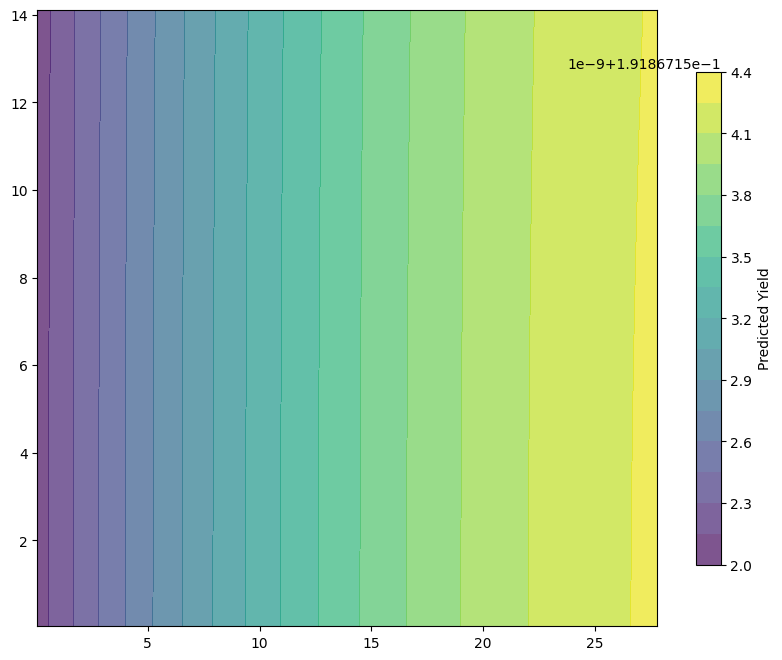

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 创建保存图片的文件夹
save_dir = 'E:/Desktop/fig_optimalround3'
os.makedirs(save_dir, exist_ok=True)  # 自动创建目录

# 加载数据并训练模型（保持原代码不变）
data1 = pd.read_csv('E:/Desktop/Yield3.csv')
data2 = pd.read_csv('E:/Desktop/Yield4.csv')
data3 = pd.read_csv('E:/Desktop/Yield5.csv')
data4 = pd.read_csv('E:/Desktop/Yield1.csv')
data5 = pd.read_csv('E:/Desktop/Yield0.csv')
data6 = pd.read_csv('E:/Desktop/Yield2.csv')
combined_data = pd.concat([data1, data2,data3,data4,data5,data6], ignore_index=True)
X = combined_data[['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']].values
y = combined_data['Yield'].values


# 使用自动相关性检测(ARD)核
kernel = C(1.0) * RBF(length_scale=[1.0]*X.shape[1], length_scale_bounds=(1e-6, 1e6))

# 增加噪声估计
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=100)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
gp.fit(X_scaled, y)


# 加载所有三轮优化点数据（新增第三轮）
first_round = pd.read_csv('E:/Desktop/Yield0.csv')
second_round = pd.read_csv('E:/Desktop/Yield3.csv')
third_round = pd.read_csv('E:/Desktop/Yield4.csv') 
#fifth_round = pd.read_csv('E:/Desktop/round4_deduplicated2.csv') 

# 定义参数范围和变量列表
variables = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
bounds = np.array([
    [0.06,27.8], [0.04,14.1], [0.296,23.55838894], [0.161,40.75],
    [0.238,29.12678742], [0.176,31.6], [0.082,6.02], [0.484,13.26]
])
fixed_values = combined_data[variables].mean(axis=0)
best_idx = combined_data['Yield'].idxmax()
best_point = combined_data.loc[best_idx, variables].values

# 遍历所有变量对生成单独图片
# 遍历所有变量对生成单独图片
for var1, var2 in combinations(variables, 2):
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    
    # 获取变量索引
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    
    # 生成网格数据
    x_grid = np.linspace(bounds[i1][0], bounds[i1][1], 50)
    y_grid = np.linspace(bounds[i2][0], bounds[i2][1], 50)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    # 构建预测样本
    grid_samples = np.tile(fixed_values, (xx.size, 1))
    grid_samples[:, i1] = xx.ravel()
    grid_samples[:, i2] = yy.ravel()
    
    # 预测并绘图
    grid_scaled = scaler.transform(grid_samples)
    mu, _ = gp.predict(grid_scaled, return_std=True)
    mu = mu.reshape(xx.shape)
    
    # 绘制热图
    contour = ax.contourf(xx, yy, mu, levels=20, cmap='viridis', alpha=0.7)
    cbar = plt.colorbar(contour, label='Predicted Yield', shrink=0.8)
    
    # ========== 关键修改 1：计算各轮次点的实际预测值 ==========
    def calc_predicted_yield(df):
        X_val = df[variables].values
        X_scaled = scaler.transform(X_val)
        return gp.predict(X_scaled)
    
    first_pred = calc_predicted_yield(first_round)
    second_pred = calc_predicted_yield(second_round)
    third_pred = calc_predicted_yield(third_round)
 
    # ========== 关键修改 2：用预测值着色散点 ==========
    vmin, vmax = min(mu.min()), max(mu.max())
    
    # 绘制所有轮次实验点（用预测值着色）
    sc1 = ax.scatter(first_round[var1], first_round[var2], 
                    c=first_pred, s=80, edgecolor='k', marker='o', 
                    cmap='viridis', vmin=vmin, vmax=vmax)
    
    sc2 = ax.scatter(second_round[var1], second_round[var2], 
                    c=second_pred, s=80, edgecolor='k', marker='s', 
                    cmap='viridis', vmin=vmin, vmax=vmax)
    
    sc3 = ax.scatter(third_round[var1], third_round[var2], 
                    c=third_pred, s=80, edgecolor='k', marker='^', 
                    cmap='viridis', vmin=vmin, vmax=vmax)
    
    
    # 添加颜色条说明
    cbar.ax.text(1.1, 1.05, "Point color = Predicted yield", 
                transform=cbar.ax.transAxes, fontsize=9)
    
    # ========== 关键修改：添加箱线图展示各轮次分布在右侧 ==========
    box_ax = inset_axes(ax, width="18%", height="40%", loc='upper right',
                        bbox_to_anchor=(0.98, 0.9, 1, 1),
                        bbox_transform=ax.transAxes, borderpad=1)

    all_preds = [first_pred, second_pred, third_pred]
    labels = ['R1', 'R2', 'R3']

    box_ax.boxplot(all_preds, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red'))
    box_ax.set_title('Predicted\nYield Dist.', fontsize=9)
    box_ax.set_ylabel('Yield', fontsize=8)
    box_ax.tick_params(axis='both', labelsize=8)
    box_ax.grid(alpha=0.3)
    
    # 绘制优化路径
    first_mean = [first_round[var1].mean(), first_round[var2].mean()]
    second_mean = [second_round[var1].mean(), second_round[var2].mean()]
    third_mean = [third_round[var1].mean(), third_round[var2].mean()]
    
    ax.plot([first_mean[0], second_mean[0], third_mean[0]],
            [first_mean[1], second_mean[1], third_mean[1]], 
            'w-', linewidth=3.5, alpha=0.9, 
            path_effects=[pe.Stroke(linewidth=5, foreground='k'), pe.Normal()])
    
    # 添加统计标注
    annotation_text = (
        f"Optimization Progress:\n"
        f"Round1 → Round2: Δ={np.linalg.norm(np.array(second_mean)-np.array(first_mean)):.2f}\n"
        f"Round2 → Round3: Δ={np.linalg.norm(np.array(third_mean)-np.array(second_mean)):.2f}\n"
    )
    ax.annotate(annotation_text, 
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.8))
    
    # 添加标题和标签
    plt.title(f"{var1} vs {var2} ", fontsize=12)
    plt.xlabel(var1, fontsize=10)
    plt.ylabel(var2, fontsize=10)
    
    # 添加图例
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Round1'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Round2'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, label='Round3'),
        Line2D([0], [0], color='white', lw=3, label='Optimization Path')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    # 保存单独图片
    filename = f"{var1}_vs_{var2}.svg"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

优化画图

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 创建保存图片的文件夹
save_dir = 'E:/Desktop/fig_optimalround5_2'
os.makedirs(save_dir, exist_ok=True)  # 自动创建目录

# 加载数据并训练模型（保持原代码不变）
data1 = pd.read_csv('E:/Desktop/Yield3.csv')
data2 = pd.read_csv('E:/Desktop/Yield4.csv')
data3 = pd.read_csv('E:/Desktop/Yield5.csv')
data4 = pd.read_csv('E:/Desktop/Yield1.csv')
data5 = pd.read_csv('E:/Desktop/Yield0.csv')
data6 = pd.read_csv('E:/Desktop/Yield2.csv')
combined_data = pd.concat([data1, data2,data3,data4,data5,data6], ignore_index=True)
X = combined_data[['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']].values
y = combined_data['Yield'].values


# 使用自动相关性检测(ARD)核
kernel = C(1.0) * RBF(length_scale=[1.0]*X.shape[1], length_scale_bounds=(1e-6, 1e6))

# 增加噪声估计
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=100)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
gp.fit(X_scaled, y)


# 加载所有三轮优化点数据（新增第三轮）
first_round = pd.read_csv('E:/Desktop/Yield1.csv')
second_round = pd.read_csv('E:/Desktop/next_top_64_filtered_points.csv')
third_round = pd.read_csv('E:/Desktop/next_top_64_filtered_points_20250512_225602.csv') 
forth_round = pd.read_csv('E:/Desktop/round4_deduplicatedall.csv') 
#fifth_round = pd.read_csv('E:/Desktop/round4_deduplicated2.csv') 

# 定义参数范围和变量列表
variables = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
bounds = np.array([
    [0.06,27.8], [0.04,14.1], [0.296,23.55838894], [0.161,40.75],
    [0.238,29.12678742], [0.176,31.6], [0.082,6.02], [0.484,13.26]
])
fixed_values = combined_data[variables].mean(axis=0)
best_idx = combined_data['Yield'].idxmax()
best_point = combined_data.loc[best_idx, variables].values

# 遍历所有变量对生成单独图片
# 遍历所有变量对生成单独图片
for var1, var2 in combinations(variables, 2):
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    
    # 获取变量索引
    i1 = variables.index(var1)
    i2 = variables.index(var2)
    
    # 生成网格数据
    x_grid = np.linspace(bounds[i1][0], bounds[i1][1], 50)
    y_grid = np.linspace(bounds[i2][0], bounds[i2][1], 50)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    # 构建预测样本
    grid_samples = np.tile(fixed_values, (xx.size, 1))
    grid_samples[:, i1] = xx.ravel()
    grid_samples[:, i2] = yy.ravel()
    
    # 预测并绘图
    grid_scaled = scaler.transform(grid_samples)
    mu, _ = gp.predict(grid_scaled, return_std=True)
    mu = mu.reshape(xx.shape)
    
    # 绘制热图
    contour = ax.contourf(xx, yy, mu, levels=20, cmap='viridis', alpha=0.7)
    cbar = plt.colorbar(contour, label='Predicted Yield', shrink=0.8)
    
    # ========== 关键修改 1：计算各轮次点的实际预测值 ==========
    def calc_predicted_yield(df):
        X_val = df[variables].values
        X_scaled = scaler.transform(X_val)
        return gp.predict(X_scaled)
    
    first_pred = calc_predicted_yield(first_round)
    second_pred = calc_predicted_yield(second_round)
    third_pred = calc_predicted_yield(third_round)
    forth_pred = calc_predicted_yield(forth_round)
    
    # ========== 关键修改 2：用预测值着色散点 ==========
    vmin, vmax = min(mu.min(), forth_pred.min()), max(mu.max(), forth_pred.max())
    
    # 绘制所有轮次实验点（用预测值着色）
    sc1 = ax.scatter(first_round[var1], first_round[var2], 
                    c=first_pred, s=80, edgecolor='k', marker='o', 
                    cmap='viridis', vmin=vmin, vmax=vmax)
    
    sc2 = ax.scatter(second_round[var1], second_round[var2], 
                    c=second_pred, s=80, edgecolor='k', marker='s', 
                    cmap='viridis', vmin=vmin, vmax=vmax)
    
    sc3 = ax.scatter(third_round[var1], third_round[var2], 
                    c=third_pred, s=80, edgecolor='k', marker='^', 
                    cmap='viridis', vmin=vmin, vmax=vmax)
    
    sc4 = ax.scatter(forth_round[var1], forth_round[var2], 
                    c=forth_pred, s=100, edgecolor='k', marker='*', 
                    cmap='viridis', vmin=vmin, vmax=vmax)
    
    # 添加颜色条说明
    cbar.ax.text(1.1, 1.05, "Point color = Predicted yield", 
                transform=cbar.ax.transAxes, fontsize=9)
    
    # ========== 关键修改：添加箱线图展示各轮次分布在右侧 ==========
    box_ax = inset_axes(ax, width="18%", height="40%", loc='upper right',
                        bbox_to_anchor=(0.98, 0.9, 1, 1),
                        bbox_transform=ax.transAxes, borderpad=1)

    all_preds = [first_pred, second_pred, third_pred, forth_pred]
    labels = ['R1', 'R2', 'R3', 'R4']

    box_ax.boxplot(all_preds, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red'))
    box_ax.set_title('Predicted\nYield Dist.', fontsize=9)
    box_ax.set_ylabel('Yield', fontsize=8)
    box_ax.tick_params(axis='both', labelsize=8)
    box_ax.grid(alpha=0.3)
    
    # 绘制优化路径
    first_mean = [first_round[var1].mean(), first_round[var2].mean()]
    second_mean = [second_round[var1].mean(), second_round[var2].mean()]
    third_mean = [third_round[var1].mean(), third_round[var2].mean()]
    forth_mean = [forth_round[var1].mean(), forth_round[var2].mean()]
    
    ax.plot([first_mean[0], second_mean[0], third_mean[0], forth_mean[0]],
            [first_mean[1], second_mean[1], third_mean[1], forth_mean[1]], 
            'w-', linewidth=3.5, alpha=0.9, 
            path_effects=[pe.Stroke(linewidth=5, foreground='k'), pe.Normal()])
    
    # 添加统计标注
    annotation_text = (
        f"Optimization Progress:\n"
        f"Round1 → Round2: Δ={np.linalg.norm(np.array(second_mean)-np.array(first_mean)):.2f}\n"
        f"Round2 → Round3: Δ={np.linalg.norm(np.array(third_mean)-np.array(second_mean)):.2f}\n"
        f"Round3 → Round4: Δ={np.linalg.norm(np.array(forth_mean)-np.array(third_mean)):.2f}\n"
        f"Round4 Avg Yield: {forth_pred.mean():.2f}±{forth_pred.std():.2f}"
    )
    ax.annotate(annotation_text, 
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.8))
    
    # 添加标题和标签
    plt.title(f"{var1} vs {var2} | Round4 Points: {len(forth_round)}", fontsize=12)
    plt.xlabel(var1, fontsize=10)
    plt.ylabel(var2, fontsize=10)
    
    # 添加图例
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Round1'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Round2'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, label='Round3'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markersize=12, label='Round4'),
        Line2D([0], [0], color='white', lw=3, label='Optimization Path')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    # 保存单独图片
    filename = f"{var1}_vs_{var2}.svg"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

d:\Users\Chestnut\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\Chestnut\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Users\Chestnut\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_2952\3624675720.py:1

In [26]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# ==================== 全局配置 ====================
BASE_PATH = 'E:/Desktop/'
INPUT_FILE = BASE_PATH + 'next_top_64_filtered_points_20250512_225602.csv'
OUTPUT_FILE = BASE_PATH + 'round4_1.csv'

VARIABLES = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
BOUNDS = np.array([
    [0.06,27.8], [0.04,14.1], [0.296,23.56], [0.161,40.75],
    [0.238,29.12678742], [0.176,31.6], [0.082,6.02], [0.484,13.26]
])

CONVERGENCE_PARAMS = {
    'initial_perturb': 0.05,
    'decay_rate': 0.9,
    'min_perturb': 0.005,
    'diversity_weight': 0.15,
    'exploit_weight': 0.85,
    'global_explore_ratio': 0.02,
    'max_stage': 5
}

# ==================== 数据准备 ====================
def load_experiment_data():
    data = []
    for exp_id in [0,1,2,3, 4, 5]:
        df = pd.read_csv(f"{BASE_PATH}Yield{exp_id}.csv")
        assert all(col in df.columns for col in VARIABLES + ['Yield']), \
               f"Yield{exp_id}.csv 缺少必要列"
        data.append(df)
    return pd.concat(data, ignore_index=True)

def check_convergence_distance(new_points, old_points, threshold=0.01):
    distances = cdist(new_points, old_points)
    min_distances = np.min(distances, axis=1)
    avg_dist = np.mean(min_distances)
    print("\n📐 新点与旧点最小距离分析：")
    print(f"平均最小距离：{avg_dist:.4f}")
    print(f"最小距离范围：{min_distances.min():.4f} ~ {min_distances.max():.4f}")

    if avg_dist < threshold:
        print("⚠️ 新点与旧点非常接近，可能已收敛过度")

def filter_too_close_candidates(new_points, old_points, threshold=0.1):
    distances = cdist(new_points, old_points)
    min_distances = np.min(distances, axis=1)
    keep_mask = min_distances > threshold
    return new_points[keep_mask], keep_mask

# ==================== 核心算法 ====================
class ConvergenceOptimizer:
    def __init__(self, gp_params=None):
        self.scaler = StandardScaler()
        self.gp = self._init_gp_model(gp_params)

    def _init_gp_model(self, params):
        default_params = {
            'kernel': C(1.0, (1e-6, 1e6)) * RBF(length_scale=0.5, length_scale_bounds=(1e-4, 1e4)),
            'n_restarts_optimizer': 20,
            'alpha': 1e-4,
            'normalize_y': True
        }
        if params: default_params.update(params)
        return GaussianProcessRegressor(**default_params)

    def _dynamic_params(self, stage):
        return {
            'perturb': max(
                CONVERGENCE_PARAMS['initial_perturb'] * (CONVERGENCE_PARAMS['decay_rate'] ** (stage*1.2)),
                CONVERGENCE_PARAMS['min_perturb']
            ),
            'explore_ratio': CONVERGENCE_PARAMS['global_explore_ratio'] * (0.8**stage),
            'exploit_weight': min(0.98, CONVERGENCE_PARAMS['exploit_weight'] * (1 + 0.15*stage)),
            'diversity_weight': CONVERGENCE_PARAMS['diversity_weight'] * (0.9**stage),
            'density_threshold': CONVERGENCE_PARAMS['initial_perturb'] * (0.7 ** stage)
        }

    def compute_gradient(self, point):
        point_scaled = self.scaler.transform([point])
        epsilon = 1e-5
        grad = np.zeros_like(point)
        for i in range(len(point)):
            delta = np.zeros_like(point_scaled)
            delta[0, i] = epsilon
            y_plus = self.gp.predict(point_scaled + delta)[0]
            y_minus = self.gp.predict(point_scaled - delta)[0]
            grad[i] = (y_plus - y_minus) / (2 * epsilon)
        return grad

    def generate_candidates(self, prev_points, stage):
        params = self._dynamic_params(stage)
        candidates = []

        if stage >= 3:
            perturbed = prev_points + np.random.normal(
                scale=params['perturb'], 
                size=(len(prev_points), len(VARIABLES))
            )
            candidates.append(np.clip(perturbed, BOUNDS[:,0], BOUNDS[:,1]))
        else:
            for _ in range(3):
                perturbed = prev_points + np.random.standard_cauchy(
                    size=(len(prev_points), len(VARIABLES))
                ) * params['perturb'] * 0.5
                candidates.append(np.clip(perturbed, BOUNDS[:,0], BOUNDS[:,1]))

                global_points = np.random.uniform(
                    low=BOUNDS[:,0], high=BOUNDS[:,1],
                    size=(int(params['explore_ratio']*len(prev_points)), len(VARIABLES))
                )
                candidates.append(global_points)

        try:
            for point in prev_points:
                grad = self.compute_gradient(point)
                grad_norm = np.linalg.norm(grad)
                if grad_norm > 1e-8:
                    grad_step = (grad / grad_norm) * params['perturb']
                    new_point = np.clip(point + grad_step, BOUNDS[:,0], BOUNDS[:,1])
                    candidates.append(new_point)
        except Exception as e:
            print(f"梯度步长计算失败: {e}")

        if stage > 1:
            scores = self.gp.predict(self.scaler.transform(prev_points))
            top_indices = np.argsort(-scores)[:len(prev_points)//2]
            for idx in top_indices:
                perturbed = prev_points[idx] + np.random.normal(
                    scale=params['perturb']*0.3,
                    size=(5, len(VARIABLES)))
                candidates.append(np.clip(perturbed, BOUNDS[:,0], BOUNDS[:,1]))

        return np.vstack(candidates)

    def select_points(self, candidates, prev_points, stage):
        X_scaled = self.scaler.transform(candidates)
        mu, sigma = self.gp.predict(X_scaled, return_std=True)

        if len(prev_points) > 0:
            prev_yield_mean = np.mean(self.gp.predict(self.scaler.transform(prev_points)))
            valid_mask = mu >= prev_yield_mean * 0.98
            candidates = candidates[valid_mask]
            mu = mu[valid_mask]
            sigma = sigma[valid_mask]

        mu_norm = (mu - mu.min()) / (mu.ptp() + 1e-8)
        sigma_norm = (sigma.max() - sigma) / (sigma.ptp() + 1e-8)
        params = self._dynamic_params(stage)
        scores = params['exploit_weight'] * mu_norm + params['diversity_weight'] * sigma_norm

        selected = []
        remaining = np.argsort(-scores)
        while len(selected) < 100 and len(remaining) > 0:
            best_idx = remaining[0]
            selected.append(best_idx)
            distances = cdist([candidates[best_idx]], candidates[remaining])
            remaining = remaining[distances[0] > params['density_threshold']]

        return candidates[selected[:100]], mu[selected[:100]]

# ==================== 主流程 ====================
if __name__ == "__main__":
    try:
        full_data = load_experiment_data()
        prev_points = pd.read_csv(INPUT_FILE)[VARIABLES].values
    except Exception as e:
        print(f"初始化错误: {str(e)}")
        exit()

    optimizer = ConvergenceOptimizer()

    try:
        X = full_data[VARIABLES].values
        y = full_data['Yield'].values
        optimizer.scaler.fit(X)
        optimizer.gp.fit(optimizer.scaler.transform(X), y)
    except Exception as e:
        print(f"模型训练错误: {str(e)}")
        exit()

    convergence_stage = len(prev_points) // 100
    if convergence_stage >= CONVERGENCE_PARAMS['max_stage']:
        print(f"已达最大收敛阶段 {CONVERGENCE_PARAMS['max_stage']}")
        exit()

    try:
        candidates = optimizer.generate_candidates(prev_points, convergence_stage)
        selected_points, predicted_yields = optimizer.select_points(candidates, prev_points, convergence_stage)
        selected_points, keep_mask = filter_too_close_candidates(selected_points, prev_points, threshold=0.1)
        predicted_yields = predicted_yields[keep_mask]

        if len(selected_points) < 100:
            print(f"⚠️ 由于与历史点接近，仅保留了 {len(selected_points)} 个点")

    except Exception as e:
        print(f"候选点生成错误: {str(e)}")
        exit()

    output_df = pd.DataFrame(selected_points, columns=VARIABLES)
    output_df['Predicted_Yield'] = predicted_yields
    output_df.sort_values('Predicted_Yield', ascending=False, inplace=True)

    if np.ptp(predicted_yields) < 0.05:
        print("警告：预测结果趋同性过高（极差<5%）")

    try:
        output_df.to_csv(OUTPUT_FILE, index=False)
        print(f"优化完成！最高预测产量：{predicted_yields.max():.4f}")
        print(f"结果保存至：{OUTPUT_FILE}")
    except Exception as e:
        print(f"结果保存错误: {str(e)}")

    print("\n收敛指标：")
    print(f"阶段：{convergence_stage}/{CONVERGENCE_PARAMS['max_stage']}")
    print(f"扰动幅度：{optimizer._dynamic_params(convergence_stage)['perturb']:.4f}")
    print(f"预测极差：{np.ptp(predicted_yields):.4f}")
    print(f"预测标准差：{np.std(predicted_yields):.4f}")
    check_convergence_distance(selected_points, prev_points)


⚠️ 由于与历史点接近，仅保留了 62 个点
优化完成！最高预测产量：0.3878
结果保存至：E:/Desktop/round4_1.csv

收敛指标：
阶段：0/5
扰动幅度：0.0500
预测极差：0.1958
预测标准差：0.0603

📐 新点与旧点最小距离分析：
平均最小距离：0.3602
最小距离范围：0.1003 ~ 1.6146


增加随机采样防止陷入局部最优

In [25]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

# ==================== 全局配置 ====================
BASE_PATH = 'E:/Desktop/'
INPUT_FILE = BASE_PATH + 'next_top_64_filtered_points_20250512_225602.csv'
OUTPUT_FILE = BASE_PATH + 'round4_3.csv'

VARIABLES = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
BOUNDS = np.array([
    [0.06,27.8], [0.04,14.1], [0.296,23.56], [0.161,40.75],
    [0.238,29.12678742], [0.176,31.6], [0.082,6.02], [0.484,13.26]
])

CONVERGENCE_PARAMS = {
    'initial_perturb': 0.03,
    'decay_rate': 0.9,
    'min_perturb': 0.005,
    'diversity_weight': 0.15,
    'exploit_weight': 0.85,
    'global_explore_ratio': 0.15,
    'max_stage': 5,
    'global_explore_samples': 10000,
    'peak_exploration_samples': 500,
    'num_peaks': 5  # 识别多个潜在峰值
}

# ==================== 数据准备 ====================
def load_experiment_data():
    data = []
    for exp_id in [0,1,2, 3, 4, 5]:
        df = pd.read_csv(f"{BASE_PATH}Yield{exp_id}.csv")
        assert all(col in df.columns for col in VARIABLES + ['Yield']), \
               f"Yield{exp_id}.csv 缺少必要列"
        data.append(df)
    return pd.concat(data, ignore_index=True)

def check_convergence_distance(new_points, old_points, threshold=0.01):
    distances = cdist(new_points, old_points)
    min_distances = np.min(distances, axis=1)
    avg_dist = np.mean(min_distances)
    print("\n📐 新点与旧点最小距离分析：")
    print(f"平均最小距离：{avg_dist:.4f}")
    print(f"最小距离范围：{min_distances.min():.4f} ~ {min_distances.max():.4f}")

    if avg_dist < threshold:
        print("⚠️ 新点与旧点非常接近，可能已收敛过度")

def filter_too_close_candidates(new_points, old_points, threshold=0.1):
    distances = cdist(new_points, old_points)
    min_distances = np.min(distances, axis=1)
    keep_mask = min_distances > threshold
    return new_points[keep_mask], keep_mask

# ==================== 核心算法 ====================
class ConvergenceOptimizer:
    def __init__(self, gp_params=None):
        self.scaler = StandardScaler()
        self.gp = self._init_gp_model(gp_params)
        self.peaks = []  # 存储多个潜在峰值
        self.peak_yields = []  # 存储峰值预测值

    def _init_gp_model(self, params):
        default_params = {
            'kernel': C(1.0, (1e-6, 1e6)) * RBF(length_scale=0.5, length_scale_bounds=(1e-5, 1e4)),
            'n_restarts_optimizer': 20,
            'alpha': 1e-4,
            'normalize_y': True
        }
        if params: default_params.update(params)
        return GaussianProcessRegressor(**default_params)

    def _dynamic_params(self, stage):
        return {
            'perturb': max(
                CONVERGENCE_PARAMS['initial_perturb'] * (CONVERGENCE_PARAMS['decay_rate'] ** (stage*1.2)),
                CONVERGENCE_PARAMS['min_perturb']
            ),
            'explore_ratio': CONVERGENCE_PARAMS['global_explore_ratio'] * (0.8**stage),
            'exploit_weight': min(0.98, CONVERGENCE_PARAMS['exploit_weight'] * (1 + 0.15*stage)),
            'diversity_weight': CONVERGENCE_PARAMS['diversity_weight'] * (0.9**stage),
            'density_threshold': CONVERGENCE_PARAMS['initial_perturb'] * (0.7 ** stage),
            'global_explore_samples': CONVERGENCE_PARAMS['global_explore_samples'],
            'peak_samples': CONVERGENCE_PARAMS['peak_exploration_samples'],
            'num_peaks': CONVERGENCE_PARAMS['num_peaks']
        }

    def compute_gradient(self, point):
        point_scaled = self.scaler.transform([point])
        epsilon = 1e-5
        grad = np.zeros_like(point)
        for i in range(len(point)):
            delta = np.zeros_like(point_scaled)
            delta[0, i] = epsilon
            y_plus = self.gp.predict(point_scaled + delta)[0]
            y_minus = self.gp.predict(point_scaled - delta)[0]
            grad[i] = (y_plus - y_minus) / (2 * epsilon)
        return grad

    def identify_peaks(self):
        """在整个搜索空间识别多个潜在峰值"""
        # 在整个搜索空间密集采样
        grid_samples = np.random.uniform(
            low=BOUNDS[:,0], high=BOUNDS[:,1],
            size=(20000, len(VARIABLES)))
        
        # 预测这些点的产量
        scaled_samples = self.scaler.transform(grid_samples)
        predictions = self.gp.predict(scaled_samples)
        
        # 找到预测产量最高的多个点
        top_indices = np.argsort(-predictions)[:CONVERGENCE_PARAMS['num_peaks']]
        self.peaks = grid_samples[top_indices]
        self.peak_yields = predictions[top_indices]
        return self.peaks, self.peak_yields

    def refine_peaks(self):
        """使用优化算法精炼峰值位置"""
        refined_peaks = []
        refined_yields = []
        
        def objective(x):
            x_scaled = self.scaler.transform([x])
            return -self.gp.predict(x_scaled)[0]  # 负号因为我们要最大化
        
        for peak in self.peaks:
            # 设置优化边界
            bounds = [(max(BOUNDS[i, 0], peak[i] - 0.5), 
                min(BOUNDS[i, 1], peak[i] + 0.5)) for i in range(len(VARIABLES))]

            
            # 使用L-BFGS-B算法进行局部优化
            result = minimize(objective, peak, method='L-BFGS-B', bounds=bounds,
                              options={'maxiter':50, 'ftol':1e-6})
            
            if result.success:
                refined_peaks.append(result.x)
                refined_yields.append(-result.fun)
            else:
                refined_peaks.append(peak)
                refined_yields.append(self.gp.predict(self.scaler.transform([peak]))[0])
        
        return np.array(refined_peaks), np.array(refined_yields)

    def generate_candidates(self, prev_points, stage):
        params = self._dynamic_params(stage)
        candidates = []

        # 1. 全局探索点 - 在整个搜索空间均匀采样
        global_points = np.random.uniform(
            low=BOUNDS[:,0], high=BOUNDS[:,1],
            size=(params['global_explore_samples'], len(VARIABLES)))
        candidates.append(global_points)

        # 2. 识别并精炼多个潜在峰值
        if self.peaks is None or np.asarray(self.peaks).size == 0:
            self.identify_peaks()
            self.peaks, self.peak_yields = self.refine_peaks()
        
        # 3. 在多个峰值周围密集采样
        for peak in self.peaks:
            peak_points = peak + np.random.normal(
                scale=0.2,  # 在峰值周围0.2标准差范围内采样
                size=(params['peak_samples']//params['num_peaks'], len(VARIABLES)))
            peak_points = np.clip(peak_points, BOUNDS[:,0], BOUNDS[:,1])
            candidates.append(peak_points)

        # 4. 历史点的扰动
        perturbed = prev_points + np.random.normal(
            scale=params['perturb'], 
            size=(len(prev_points), len(VARIABLES)))
        candidates.append(np.clip(perturbed, BOUNDS[:,0], BOUNDS[:,1]))

        # 5. 梯度步长
        try:
            for point in prev_points:
                grad = self.compute_gradient(point)
                grad_norm = np.linalg.norm(grad)
                if grad_norm > 1e-8:
                    grad_step = (grad / grad_norm) * params['perturb']
                    new_point = np.clip(point + grad_step, BOUNDS[:,0], BOUNDS[:,1])
                    candidates.append(new_point)
        except Exception as e:
            print(f"梯度步长计算失败: {e}")

        # 6. 历史高点的扰动
        scores = self.gp.predict(self.scaler.transform(prev_points))
        top_indices = np.argsort(-scores)[:min(10, len(prev_points)//3)]
        for idx in top_indices:
            perturbed = prev_points[idx] + np.random.normal(
                scale=params['perturb']*0.5,
                size=(3, len(VARIABLES)))
            candidates.append(np.clip(perturbed, BOUNDS[:,0], BOUNDS[:,1]))

        return np.vstack(candidates)

    def select_points(self, candidates, prev_points, stage):
        X_scaled = self.scaler.transform(candidates)
        mu, sigma = self.gp.predict(X_scaled, return_std=True)

        # 强制包含精炼后的峰值点
        for peak in self.peaks:
            # 检查峰值点是否在候选点中
            distances = cdist([peak], candidates)
            if np.min(distances) > 1e-6:
                # 如果不在，则添加
                candidates = np.vstack([candidates, peak])
                mu_peak = self.gp.predict(self.scaler.transform([peak]))[0]
                mu = np.append(mu, mu_peak)
                sigma = np.append(sigma, 0)  # 添加标准差为0

        # 选择策略：优先选择高产区域
        params = self._dynamic_params(stage)
        
        # 动态调整权重：早期更注重探索，后期更注重利用
        if stage < 2:
            exploit_weight = 0.6
            diversity_weight = 0.4
        else:
            exploit_weight = params['exploit_weight']
            diversity_weight = params['diversity_weight']
            
        # 标准化
        mu_norm = (mu - mu.min()) / (mu.ptp() + 1e-8)
        sigma_norm = (sigma.max() - sigma) / (sigma.ptp() + 1e-8)
        scores = exploit_weight * mu_norm + diversity_weight * sigma_norm

        # 选择策略：确保覆盖所有预测峰值
        selected = []
        
        # 首先强制包含所有精炼峰值点
        for peak in self.peaks:
            # 找到候选点中最接近峰值的点
            distances = cdist([peak], candidates)
            closest_idx = np.argmin(distances)
            if closest_idx not in selected:
                selected.append(closest_idx)
        
        # 然后添加其他高分点
        remaining = np.argsort(-scores)
        for idx in remaining:
            if idx not in selected:
                selected.append(idx)
            if len(selected) >= 200:
                break

        return candidates[selected[:200]], mu[selected[:200]]

# ==================== 主流程 ====================
if __name__ == "__main__":
    try:
        full_data = load_experiment_data()
        prev_points = pd.read_csv(INPUT_FILE)[VARIABLES].values
    except Exception as e:
        print(f"初始化错误: {str(e)}")
        exit()

    optimizer = ConvergenceOptimizer()

    try:
        X = full_data[VARIABLES].values
        y = full_data['Yield'].values
        optimizer.scaler.fit(X)
        optimizer.gp.fit(optimizer.scaler.transform(X), y)
        
        # 识别并精炼多个潜在峰值
        peaks, peak_yields = optimizer.identify_peaks()
        refined_peaks, refined_yields = optimizer.refine_peaks()
        
        print("🔍 识别到的潜在峰值:")
        for i, (peak, yield_val) in enumerate(zip(refined_peaks, refined_yields)):
            print(f"峰值 {i+1}: 位置={peak}, 预测产量={yield_val:.4f}")
    except Exception as e:
        print(f"模型训练错误: {str(e)}")
        import traceback
        traceback.print_exc()
        exit()

    convergence_stage = len(prev_points) // 200
    if convergence_stage >= CONVERGENCE_PARAMS['max_stage']:
        print(f"已达最大收敛阶段 {CONVERGENCE_PARAMS['max_stage']}")
        exit()

    try:
        candidates = optimizer.generate_candidates(prev_points, convergence_stage)
        selected_points, predicted_yields = optimizer.select_points(candidates, prev_points, convergence_stage)
        
        # 检查峰值点是否在最终选择中
        for i, peak in enumerate(refined_peaks):
            distances = cdist([peak], selected_points)
            min_dist = np.min(distances)
            print(f"峰值 {i+1} 到最近采样点的距离: {min_dist:.6f}")
            if min_dist > 0.1:
                print(f"⚠️ 警告: 峰值 {i+1} 未被采样点覆盖!")
                # 直接替换预测值最低的点
                min_idx = np.argmin(predicted_yields)
                selected_points[min_idx] = peak
                predicted_yields[min_idx] = refined_yields[i]
        
        # 过滤太接近的点
        selected_points, keep_mask = filter_too_close_candidates(selected_points, prev_points, threshold=0.1)
        predicted_yields = predicted_yields[keep_mask]

        # 确保最终有64个点
        if len(selected_points) > 200:
            # 保留预测值最高的64个点
            top_indices = np.argsort(-predicted_yields)[:200]
            selected_points = selected_points[top_indices]
            predicted_yields = predicted_yields[top_indices]
        elif len(selected_points) < 200:
            # 补充随机点
            num_needed = 200 - len(selected_points)
            random_points = np.random.uniform(
                low=BOUNDS[:,0], high=BOUNDS[:,1],
                size=(num_needed, len(VARIABLES)))
            random_yields = optimizer.gp.predict(optimizer.scaler.transform(random_points))
            selected_points = np.vstack([selected_points, random_points])
            predicted_yields = np.concatenate([predicted_yields, random_yields])

    except Exception as e:
        print(f"候选点生成错误: {str(e)}")
        import traceback
        traceback.print_exc()
        exit()

    output_df = pd.DataFrame(selected_points, columns=VARIABLES)
    output_df['Predicted_Yield'] = predicted_yields
    output_df.sort_values('Predicted_Yield', ascending=False, inplace=True)

    # 检查预测值分布
    yield_range = np.ptp(predicted_yields)
    if yield_range < 0.05:
        print(f"警告：预测结果趋同性过高（极差={yield_range:.4f}）")
    else:
        print(f"预测值范围：{predicted_yields.min():.4f} - {predicted_yields.max():.4f}")

    try:
        output_df.to_csv(OUTPUT_FILE, index=False)
        print(f"优化完成！最高预测产量：{predicted_yields.max():.4f}")
        print(f"结果保存至：{OUTPUT_FILE}")
    except Exception as e:
        print(f"结果保存错误: {str(e)}")

    print("\n收敛指标：")
    print(f"阶段：{convergence_stage}/{CONVERGENCE_PARAMS['max_stage']}")
    print(f"扰动幅度：{optimizer._dynamic_params(convergence_stage)['perturb']:.4f}")
    print(f"预测极差：{yield_range:.4f}")
    print(f"预测标准差：{np.std(predicted_yields):.4f}")
    check_convergence_distance(selected_points, prev_points)
    
    # 检查峰值覆盖情况
    print("\n峰值覆盖检查:")
    for i, peak in enumerate(refined_peaks):
        distances = cdist([peak], selected_points)
        min_dist = np.min(distances)
        print(f"峰值 {i+1} 到最近采样点距离: {min_dist:.6f}")
        if min_dist > 0.1:
            print(f"⚠️ 警告: 峰值 {i+1} 未被充分覆盖!")

d:\Users\Chestnut\anaconda3\lib\site-packages\sklearn\gaussian_process\_gpr.py:610: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


🔍 识别到的潜在峰值:
峰值 1: 位置=[ 3.53875966  0.89511455 14.23604103 10.97706406 10.55246464 14.05834826
  2.14840925  2.03657266], 预测产量=0.3366
峰值 2: 位置=[ 2.1728986   0.90108113 16.39353288 11.16744981 11.66950915 27.1535891
  2.2972046   1.97591459], 预测产量=0.3649
峰值 3: 位置=[ 6.07795246  6.37882726 12.1489914   3.18786167  9.14602261 17.59731647
  2.90617595  1.11705889], 预测产量=0.3033
峰值 4: 位置=[ 4.14498946  2.75995938 12.12079585 11.15002633 10.34595701 27.41950969
  2.75444264  1.59315218], 预测产量=0.3628
峰值 5: 位置=[ 4.23664952  4.29539626 11.15709717 12.58627676 10.86507315 26.63159234
  2.45135538  2.41538712], 预测产量=0.3151
峰值 1 到最近采样点的距离: 0.961850
⚠️ 警告: 峰值 1 未被采样点覆盖!
峰值 2 到最近采样点的距离: 1.338004
⚠️ 警告: 峰值 2 未被采样点覆盖!
峰值 3 到最近采样点的距离: 1.343582
⚠️ 警告: 峰值 3 未被采样点覆盖!
峰值 4 到最近采样点的距离: 0.816608
⚠️ 警告: 峰值 4 未被采样点覆盖!
峰值 5 到最近采样点的距离: 1.174671
⚠️ 警告: 峰值 5 未被采样点覆盖!
预测值范围：0.1560 - 0.3853
优化完成！最高预测产量：0.3853
结果保存至：E:/Desktop/round4_3.csv

收敛指标：
阶段：0/5
扰动幅度：0.0300
预测极差：0.2293
预测标准差：0.0693

📐 新点与旧点最小距离分析：
平均最小距离：10.6550
最

随机采样

In [28]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
import os
import time

# ==================== 全局配置 ====================
BASE_PATH = 'E:/Desktop/'
OUTPUT_FILE = BASE_PATH + 'autonomous_optimization.csv'  # 输出文件名

VARIABLES = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
BOUNDS = np.array([
    [0.06,27.8], [0.04,14.1], [0.296,23.56], [0.161,40.75],
    [0.238,29.12678742], [0.176,31.6], [0.082,6.02], [0.484,13.26]
])

CONVERGENCE_PARAMS = {
    'initial_perturb': 0.05,  # 增大初始扰动范围
    'decay_rate': 0.85,       # 减缓衰减速度
    'min_perturb': 0.005,
    'diversity_weight': 0.25, # 提高多样性权重
    'exploit_weight': 0.75,
    'global_explore_ratio': 0.25,
    'max_stage': 6,           # 增加最大阶段数
    'global_explore_samples': 2000000,  # 增加全局探索样本
    'peak_exploration_samples': 100000, # 增加峰值探索样本
    'num_peaks': 8,           # 增加峰值数量
    'convergence_threshold': 0.008,  # 收敛距离阈值
    'min_improvement': 0.01,  # 最小改进阈值
    'min_yield_range': 0.05   # 最小预测值范围
}

# ==================== 数据准备 ====================
def load_experiment_data():
    """加载所有可用实验数据"""
    data = []
    for exp_id in [0,1,2, 3, 4, 5]:
        file_path = f"{BASE_PATH}Yield{exp_id}.csv"
        if os.path.exists(file_path):
            try:
                df = pd.read_csv(file_path)
                assert all(col in df.columns for col in VARIABLES + ['Yield']), \
                       f"Yield{exp_id}.csv 缺少必要列"
                data.append(df)
                print(f"✅ 成功加载: {file_path} ({len(df)} 条数据)")
            except Exception as e:
                print(f"⚠️ 加载 {file_path} 失败: {str(e)}")
        else:
            print(f"⚠️ 文件不存在: {file_path}")
    
    if not data:
        raise ValueError("❌ 没有可用的实验数据，无法进行优化")
    
    combined = pd.concat(data, ignore_index=True)
    print(f"📊 合并后总数据量: {len(combined)} 条")
    return combined

def check_convergence_distance(new_points, old_points, threshold=0.1):
    """检查新点与旧点的距离收敛情况"""
    if len(old_points) == 0:
        return 1.0  # 没有旧点，返回最大距离
    
    distances = cdist(new_points, old_points)
    min_distances = np.min(distances, axis=1)
    avg_dist = np.mean(min_distances)
    print("\n📐 新点与旧点最小距离分析：")
    print(f"平均最小距离：{avg_dist:.4f}")
    print(f"最小距离范围：{min_distances.min():.4f} ~ {min_distances.max():.4f}")

    if avg_dist < threshold:
        print(f"⚠️ 新点与旧点非常接近（平均距离={avg_dist:.4f}<{threshold:.4f}），可能已收敛")
    return avg_dist

def filter_too_close_candidates(new_points, old_points, threshold=0.1):
    """过滤与历史点过于接近的候选点"""
    if len(old_points) == 0:
        return new_points, np.ones(len(new_points), dtype=bool)
    
    distances = cdist(new_points, old_points)
    min_distances = np.min(distances, axis=1)
    keep_mask = min_distances > threshold
    filtered_count = len(keep_mask) - np.sum(keep_mask)
    
    if filtered_count > 0:
        print(f"🔍 过滤掉 {filtered_count} 个与历史点过近的候选点")
    
    return new_points[keep_mask], keep_mask

# ==================== 核心算法 ====================
class AutonomousOptimizer:
    def __init__(self, gp_params=None):
        self.scaler = StandardScaler()
        self.gp = self._init_gp_model(gp_params)
        self.peaks = np.array([])  # 存储多个潜在峰值
        self.peak_yields = np.array([])  # 存储峰值预测值
        self.best_yield = 0.0  # 追踪最佳产量
        self.all_evaluated_points = np.empty((0, len(VARIABLES)))  # 所有评估过的点
        self.all_yields = np.array([])  # 对应的产量值

    def _init_gp_model(self, params):
        """初始化高斯过程模型"""
        default_params = {
            'kernel': C(1.0, (1e-6, 1e6)) * RBF(length_scale=0.5, length_scale_bounds=(1e-5, 1e4)),
            'n_restarts_optimizer': 25,  # 增加重启次数
            'alpha': 1e-4,
            'normalize_y': True,
            'random_state': 42  # 固定随机种子
        }
        if params: 
            default_params.update(params)
        return GaussianProcessRegressor(**default_params)

    def _dynamic_params(self, stage):
        """动态调整算法参数"""
        return {
            'perturb': max(
                CONVERGENCE_PARAMS['initial_perturb'] * (CONVERGENCE_PARAMS['decay_rate'] ** (stage*1.2)),
                CONVERGENCE_PARAMS['min_perturb']
            ),
            'explore_ratio': CONVERGENCE_PARAMS['global_explore_ratio'] * (0.8**stage),
            'exploit_weight': min(0.98, CONVERGENCE_PARAMS['exploit_weight'] * (1 + 0.15*stage)),
            'diversity_weight': CONVERGENCE_PARAMS['diversity_weight'] * (0.9**stage),
            'density_threshold': CONVERGENCE_PARAMS['initial_perturb'] * (0.7 ** stage),
            'global_explore_samples': CONVERGENCE_PARAMS['global_explore_samples'],
            'peak_samples': CONVERGENCE_PARAMS['peak_exploration_samples'],
            'num_peaks': CONVERGENCE_PARAMS['num_peaks']
        }

    def compute_gradient(self, point):
        """计算指定点的预测产量梯度"""
        point_scaled = self.scaler.transform([point])
        epsilon = 1e-5
        grad = np.zeros_like(point)
        for i in range(len(point)):
            delta = np.zeros_like(point_scaled)
            delta[0, i] = epsilon
            y_plus = self.gp.predict(point_scaled + delta)[0]
            y_minus = self.gp.predict(point_scaled - delta)[0]
            grad[i] = (y_plus - y_minus) / (2 * epsilon)
        return grad

    def identify_peaks(self):
        """在整个搜索空间识别多个潜在峰值"""
        # 在整个搜索空间密集采样
        grid_samples = np.random.uniform(
            low=BOUNDS[:,0], high=BOUNDS[:,1],
            size=(200000, len(VARIABLES)))
        
        # 预测这些点的产量
        scaled_samples = self.scaler.transform(grid_samples)
        predictions = self.gp.predict(scaled_samples)
        
        # 找到预测产量最高的多个点
        top_indices = np.argsort(-predictions)[:CONVERGENCE_PARAMS['num_peaks']]
        self.peaks = grid_samples[top_indices]
        self.peak_yields = predictions[top_indices]
        return self.peaks, self.peak_yields

    def refine_peaks(self):
        """使用优化算法精炼峰值位置"""
        if self.peaks.size == 0:
            return np.array([]), np.array([])
            
        refined_peaks = []
        refined_yields = []
        
        def objective(x):
            x_scaled = self.scaler.transform([x])
            return -self.gp.predict(x_scaled)[0]  # 负号因为我们要最大化
        
        for peak in self.peaks:
            # 设置优化边界（在峰值周围0.5范围内）
            bounds = [(max(BOUNDS[i, 0], peak[i] - 0.5), 
                      min(BOUNDS[i, 1], peak[i] + 0.5)) for i in range(len(VARIABLES))]
            
            # 使用L-BFGS-B算法进行局部优化
            result = minimize(objective, peak, method='L-BFGS-B', bounds=bounds,
                              options={'maxiter':100, 'ftol':1e-7})
            
            if result.success:
                refined_peaks.append(result.x)
                refined_yields.append(-result.fun)
            else:
                refined_peaks.append(peak)
                refined_yields.append(self.gp.predict(self.scaler.transform([peak]))[0])
        
        return np.array(refined_peaks), np.array(refined_yields)

    def generate_candidates(self, stage):
        """生成候选点集"""
        params = self._dynamic_params(stage)
        candidates = []

        # 1. 全局探索点 - 在整个搜索空间均匀采样
        global_samples = params['global_explore_samples']
        global_points = np.random.uniform(
            low=BOUNDS[:,0], high=BOUNDS[:,1],
            size=(global_samples, len(VARIABLES)))
        candidates.append(global_points)
        print(f"🌍 全局探索点: {global_samples} 个")

        # 2. 识别潜在峰值（如果没有历史点或首次运行）
        if self.peaks.size == 0 or stage == 0:
            print("🔍 识别潜在峰值...")
            self.identify_peaks()
        
        # 精炼峰值
        if self.peaks.size > 0:
            print("🛠️ 精炼峰值位置...")
            self.peaks, self.peak_yields = self.refine_peaks()
            
            # 3. 在多个峰值周围密集采样
            peak_samples = params['peak_samples'] // max(1, len(self.peaks))
            for i, peak in enumerate(self.peaks):
                peak_points = peak + np.random.normal(
                    scale=max(0.1, 0.5 * (0.9**stage)),  # 随阶段衰减
                    size=(peak_samples, len(VARIABLES)))
                peak_points = np.clip(peak_points, BOUNDS[:,0], BOUNDS[:,1])
                candidates.append(peak_points)
                print(f"🏔️ 峰值 {i+1} 周围采样: {peak_samples} 个 (预测产量={self.peak_yields[i]:.4f})")
        
        # 4. 如果有评估过的点，进行扰动和梯度优化
        if len(self.all_evaluated_points) > 0:
            # 历史点扰动
            perturbed = self.all_evaluated_points + np.random.normal(
                scale=params['perturb'], 
                size=(len(self.all_evaluated_points), len(VARIABLES)))
            perturbed = np.clip(perturbed, BOUNDS[:,0], BOUNDS[:,1])
            candidates.append(perturbed)
            print(f"🔄 历史点扰动: {len(self.all_evaluated_points)} 个")
            
            # 梯度步长
            try:
                grad_points = []
                for point in self.all_evaluated_points:
                    grad = self.compute_gradient(point)
                    grad_norm = np.linalg.norm(grad)
                    if grad_norm > 1e-8:
                        grad_step = (grad / grad_norm) * params['perturb']
                        new_point = np.clip(point + grad_step, BOUNDS[:,0], BOUNDS[:,1])
                        grad_points.append(new_point)
                if grad_points:
                    candidates.append(np.array(grad_points))
                    print(f"📈 梯度步长点: {len(grad_points)} 个")
            except Exception as e:
                print(f"梯度步长计算失败: {e}")

            # 历史高点的扰动
            if len(self.all_evaluated_points) > 5:
                scores = self.gp.predict(self.scaler.transform(self.all_evaluated_points))
                top_indices = np.argsort(-scores)[:min(10, len(self.all_evaluated_points)//2)]
                high_points = []
                for idx in top_indices:
                    perturbed = self.all_evaluated_points[idx] + np.random.normal(
                        scale=params['perturb']*0.3,
                        size=(3, len(VARIABLES)))
                    high_points.append(perturbed)
                if high_points:
                    candidates.append(np.vstack(high_points))
                    print(f"⭐ 历史高点扰动: {len(high_points)*3} 个")

        return np.vstack(candidates)

    def select_points(self, candidates):
        """从候选点中选择下一批实验点"""
        X_scaled = self.scaler.transform(candidates)
        mu, sigma = self.gp.predict(X_scaled, return_std=True)

        # 添加精炼后的峰值点（如果不在候选点中）
        if self.peaks.size > 0:
            for peak in self.peaks:
                distances = cdist([peak], candidates)
                if np.min(distances) > 1e-6:
                    candidates = np.vstack([candidates, peak])
                    mu_peak = self.gp.predict(self.scaler.transform([peak]))[0]
                    mu = np.append(mu, mu_peak)
                    sigma = np.append(sigma, 0)  # 添加标准差为0

        # 动态调整权重
        stage = len(self.all_evaluated_points) // 200
        params = self._dynamic_params(stage)
        
        # 早期更注重探索，后期更注重利用
        if stage < 2:
            exploit_weight = 0.6
            diversity_weight = 0.4
        else:
            exploit_weight = params['exploit_weight']
            diversity_weight = params['diversity_weight']
            
        # 标准化分数
        mu_norm = (mu - mu.min()) / (mu.ptp() + 1e-8)
        sigma_norm = (sigma.max() - sigma) / (sigma.ptp() + 1e-8)
        scores = exploit_weight * mu_norm + diversity_weight * sigma_norm

        # 选择策略：确保覆盖所有预测峰值
        selected_indices = []
        
        # 1. 强制包含所有精炼峰值点
        if self.peaks.size > 0:
            for peak in self.peaks:
                distances = cdist([peak], candidates)
                closest_idx = np.argmin(distances)
                if closest_idx not in selected_indices:
                    selected_indices.append(closest_idx)
                    print(f"📌 强制包含峰值点: {peak} (预测产量={mu[closest_idx]:.4f})")
        
        # 2. 添加其他高分点
        remaining_indices = np.argsort(-scores)
        for idx in remaining_indices:
            if idx not in selected_indices:
                selected_indices.append(idx)
            if len(selected_indices) >= 200:
                break

        selected_points = candidates[selected_indices[:200]]
        selected_yields = mu[selected_indices[:200]]
        
        # 更新最佳产量
        current_best = np.max(selected_yields)
        if current_best > self.best_yield:
            improvement = current_best - self.best_yield
            self.best_yield = current_best
            print(f"🚀 发现新最佳预测产量: {self.best_yield:.4f} (提升 +{improvement:.4f})")
        
        return selected_points, selected_yields

    def update_model(self, new_points, new_yields):
        """用新实验数据更新模型"""
        # 添加到历史数据
        self.all_evaluated_points = np.vstack([self.all_evaluated_points, new_points])
        self.all_yields = np.concatenate([self.all_yields, new_yields])
        
        # 重新训练模型
        X_scaled = self.scaler.transform(self.all_evaluated_points)
        self.gp.fit(X_scaled, self.all_yields)
        
        # 重新识别峰值
        self.peaks = np.array([])
        self.identify_peaks()
        self.refine_peaks()

# ==================== 主流程 ====================
def main():
    # 加载实验数据
    try:
        full_data = load_experiment_data()
        print(f"📊 总实验数据量: {len(full_data)} 条")
    except Exception as e:
        print(f"❌ 数据加载失败: {str(e)}")
        return
    
    # 初始化优化器
    optimizer = AutonomousOptimizer()
    
    # 准备训练数据
    X = full_data[VARIABLES].values
    y = full_data['Yield'].values
    
    # 初始训练GP模型
    try:
        optimizer.scaler.fit(X)
        optimizer.gp.fit(optimizer.scaler.transform(X), y)
        print(f"✅ 高斯过程模型训练完成 (初始样本数={len(X)})")
        
        # 保存初始数据到历史记录
        optimizer.all_evaluated_points = X
        optimizer.all_yields = y
    except Exception as e:
        print(f"❌ 模型训练错误: {str(e)}")
        return
    
    # 确定当前收敛阶段
    convergence_stage = len(optimizer.all_evaluated_points) // 200
    print(f"\n🔁 当前收敛阶段: {convergence_stage}/{CONVERGENCE_PARAMS['max_stage']}")
    
    # 检查收敛条件
    if convergence_stage >= CONVERGENCE_PARAMS['max_stage']:
        print(f"⏹️ 已达最大收敛阶段 {CONVERGENCE_PARAMS['max_stage']}")
        return
    
    # 生成候选点
    try:
        start_time = time.time()
        candidates = optimizer.generate_candidates(convergence_stage)
        gen_time = time.time() - start_time
        print(f"📋 生成候选点总数: {len(candidates)} (耗时: {gen_time:.2f}秒)")
        
        # 选择实验点
        start_time = time.time()
        selected_points, predicted_yields = optimizer.select_points(candidates)
        sel_time = time.time() - start_time
        print(f"🎯 选择实验点: {len(selected_points)} 个 (耗时: {sel_time:.2f}秒)")
    except Exception as e:
        print(f"❌ 候选点生成错误: {str(e)}")
        return
    
    # 检查峰值覆盖
    if optimizer.peaks.size > 0:
        print("\n🔍 峰值覆盖检查:")
        for i, peak in enumerate(optimizer.peaks):
            distances = cdist([peak], selected_points)
            min_dist = np.min(distances)
            print(f"峰值 {i+1} 到最近采样点距离: {min_dist:.6f}")
            if min_dist > 0.1:
                print(f"⚠️ 警告: 峰值 {i+1} 未被充分覆盖!")
    
    # 过滤太接近的点
    filtered_points, keep_mask = filter_too_close_candidates(
        selected_points, 
        optimizer.all_evaluated_points,
        threshold=CONVERGENCE_PARAMS['convergence_threshold']
    )
    filtered_yields = predicted_yields[keep_mask]
    
    # 确保最终有64个点
    if len(filtered_points) > 200:
        # 保留预测值最高的64个点
        top_indices = np.argsort(-filtered_yields)[:200]
        filtered_points = filtered_points[top_indices]
        filtered_yields = filtered_yields[top_indices]
    elif len(filtered_points) < 200:
        # 补充随机点
        num_needed = 200 - len(filtered_points)
        random_points = np.random.uniform(
            low=BOUNDS[:,0], high=BOUNDS[:,1],
            size=(num_needed, len(VARIABLES)))
        random_yields = optimizer.gp.predict(optimizer.scaler.transform(random_points))
        filtered_points = np.vstack([filtered_points, random_points])
        filtered_yields = np.concatenate([filtered_yields, random_yields])
        print(f"🔢 补充 {num_needed} 个随机点")
    
    # 创建输出DataFrame
    output_df = pd.DataFrame(filtered_points, columns=VARIABLES)
    output_df['Predicted_Yield'] = filtered_yields
    output_df.sort_values('Predicted_Yield', ascending=False, inplace=True)
    
    # 分析预测结果
    yield_min, yield_max = filtered_yields.min(), filtered_yields.max()
    yield_range = yield_max - yield_min
    yield_std = np.std(filtered_yields)
    
    print("\n📊 预测结果分析:")
    print(f"预测值范围: {yield_min:.4f} - {yield_max:.4f} (极差={yield_range:.4f})")
    print(f"预测标准差: {yield_std:.4f}")
    
    # 检查收敛情况
    avg_dist = check_convergence_distance(
        filtered_points, 
        optimizer.all_evaluated_points,
        threshold=CONVERGENCE_PARAMS['convergence_threshold']
    )
    
    # 检查预测值范围
    if yield_range < CONVERGENCE_PARAMS['min_yield_range']:
        print(f"⚠️ 预测值范围过小 ({yield_range:.4f}<{CONVERGENCE_PARAMS['min_yield_range']:.4f})")
    
    # 保存结果
    try:
        output_df.to_csv(OUTPUT_FILE, index=False)
        print(f"\n✅ 优化完成! 结果保存至: {OUTPUT_FILE}")
        print(f"🏆 最高预测产量: {yield_max:.4f}")
        
        # 保存峰值信息
        if optimizer.peaks.size > 0:
            peak_df = pd.DataFrame(optimizer.peaks, columns=VARIABLES)
            peak_df['Predicted_Yield'] = optimizer.peak_yields
            peak_df.to_csv(BASE_PATH + 'identified_peaks.csv', index=False)
            print(f"💡 识别到的峰值保存至: {BASE_PATH}identified_peaks.csv")
    except Exception as e:
        print(f"❌ 结果保存错误: {str(e)}")
    
    # 建议下一轮实验
    print("\n📌 建议:")
    if avg_dist < CONVERGENCE_PARAMS['convergence_threshold']:
        print("1. 已收敛，建议进行最终验证实验")
    else:
        print("1. 执行本轮实验后，用新数据更新模型")
    print("2. 关注已识别的峰值区域")
    print(f"3. 重点关注预测值 > {yield_max * 0.95:.4f} 的点")

if __name__ == "__main__":
    print("="*60)
    start_time = time.time()
    
    main()

✅ 成功加载: E:/Desktop/Yield0.csv (76 条数据)
✅ 成功加载: E:/Desktop/Yield1.csv (71 条数据)
✅ 成功加载: E:/Desktop/Yield2.csv (71 条数据)
✅ 成功加载: E:/Desktop/Yield3.csv (141 条数据)
✅ 成功加载: E:/Desktop/Yield4.csv (64 条数据)
✅ 成功加载: E:/Desktop/Yield5.csv (63 条数据)
📊 合并后总数据量: 486 条
📊 总实验数据量: 486 条


d:\Users\Chestnut\anaconda3\lib\site-packages\sklearn\gaussian_process\_gpr.py:610: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


✅ 高斯过程模型训练完成 (初始样本数=486)

🔁 当前收敛阶段: 2/6
🌍 全局探索点: 2000000 个
🔍 识别潜在峰值...
🛠️ 精炼峰值位置...
🏔️ 峰值 1 周围采样: 12500 个 (预测产量=0.5127)
🏔️ 峰值 2 周围采样: 12500 个 (预测产量=0.5296)
🏔️ 峰值 3 周围采样: 12500 个 (预测产量=0.5938)
🏔️ 峰值 4 周围采样: 12500 个 (预测产量=0.5196)
🏔️ 峰值 5 周围采样: 12500 个 (预测产量=0.4430)
🏔️ 峰值 6 周围采样: 12500 个 (预测产量=0.4166)
🏔️ 峰值 7 周围采样: 12500 个 (预测产量=0.3996)
🏔️ 峰值 8 周围采样: 12500 个 (预测产量=0.3687)
🔄 历史点扰动: 486 个
📈 梯度步长点: 483 个
⭐ 历史高点扰动: 30 个
📋 生成候选点总数: 2100999 (耗时: 4.59秒)
❌ 候选点生成错误: Unable to allocate 7.61 GiB for an array with shape (2100999, 486) and data type float64


In [38]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

# 设置文件路径
round4_path = "E:/Desktop/autonomous_optimization.csv"
output_path = "E:/Desktop/autonomous_deduplicated.csv"
old_files = [
    'E:/Desktop/Yield1.csv',
    'E:/Desktop/next_top_64_filtered_points.csv',
    'E:/Desktop/top_64_filtered_points.csv',
    'E:/Desktop/next_top_64_filtered_points_20250512_225602.csv',
    'E:/Desktop/Yield3.csv',
    'E:/Desktop/Yield4.csv',
    'E:/Desktop/Yield5.csv',
    'E:/Desktop/Yield0.csv'
]

VARIABLES = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
DIST_THRESHOLD = 0.7
YIELD_COL = 'Predicted_Yield'  # 假设该列用于比较大小

# Step 1: 读取新点数据
round4_df = pd.read_csv(round4_path)
round4_points = round4_df[VARIABLES].to_numpy()

# Step 2: 读取旧点数据
old_dfs = [pd.read_csv(f) for f in old_files]
combined_old_df = pd.concat(old_dfs, ignore_index=True)
old_points = combined_old_df[VARIABLES].to_numpy()

# Step 3: 删除与旧点过近的新点
nn_old = NearestNeighbors(radius=DIST_THRESHOLD, metric='euclidean')
nn_old.fit(old_points)
_, indices_old = nn_old.radius_neighbors(round4_points)
is_similar_to_old = [len(neighs) > 0 for neighs in indices_old]
filtered_df = round4_df[~np.array(is_similar_to_old)].copy()
filtered_points = filtered_df[VARIABLES].to_numpy()

print(f"与旧数据去重后剩余点数：{len(filtered_df)}")

# Step 4: 新点内部去重，保留 Yield 更大的点
nn_self = NearestNeighbors(radius=DIST_THRESHOLD, metric='euclidean')
nn_self.fit(filtered_points)
_, indices_self = nn_self.radius_neighbors(filtered_points)

n = len(filtered_points)
keep_mask = np.ones(n, dtype=bool)
visited = np.zeros(n, dtype=bool)

for i in range(n):
    if visited[i]:
        continue
    group = indices_self[i]
    group = [idx for idx in group if not visited[idx]]
    if len(group) <= 1:
        visited[i] = True
        continue
    yields = filtered_df.iloc[group][YIELD_COL].values
    max_idx = group[np.argmax(yields)]
    for idx in group:
        keep_mask[idx] = (idx == max_idx)
        visited[idx] = True

final_df = filtered_df[keep_mask].copy()

print(f"内部去重后剩余点数：{len(final_df)}")

# 保存结果

final_df.to_csv(output_path, index=False)
print(f"最终输出路径：{output_path}")


与旧数据去重后剩余点数：59
内部去重后剩余点数：15
最终输出路径：E:/Desktop/autonomous_deduplicated.csv


In [45]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

files = [
    "E:/Desktop/round4_deduplicated1.csv",
    "E:/Desktop/round4_deduplicated2.csv",
    "E:/Desktop/round4_deduplicated3.csv",
    "E:/Desktop/round4_deduplicated5.csv",
    "E:/Desktop/round4_deduplicated6.csv",
    #"E:/Desktop/autonomous_deduplicated.csv"

]

VARIABLES = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
DIST_THRESHOLD = 5  # 可调阈值
YIELD_COL = 'Predicted_Yield'  # 你之前用的Yield列名
PREDICTED_YIELD_COL = 'Predicted_Yield'  # 你想排序用的列名

# 读取并合并
dfs = [pd.read_csv(f) for f in files]
combined_df = pd.concat(dfs, ignore_index=True)
combined_points = combined_df[VARIABLES].to_numpy()

print(f"合并后总点数: {len(combined_df)}")

# 计算邻居（包括自己）
nn = NearestNeighbors(radius=DIST_THRESHOLD, metric='euclidean')
nn.fit(combined_points)
_, neighbors = nn.radius_neighbors(combined_points)

n = len(combined_points)
keep_mask = np.ones(n, dtype=bool)  # 初始都保留
visited = np.zeros(n, dtype=bool)    # 标记已处理点

for i in range(n):
    if visited[i]:
        continue
    group = neighbors[i]  # i 点的邻居，包括自己
    # 过滤掉已经被其他点处理过的邻居，只处理新的
    group = [idx for idx in group if not visited[idx]]
    if len(group) <= 1:
        visited[i] = True
        continue
    # 找 Yield 最大的点保留，其他删
    yields = combined_df.loc[group, YIELD_COL].values
    max_idx_in_group = group[np.argmax(yields)]
    for idx in group:
        keep_mask[idx] = (idx == max_idx_in_group)
        visited[idx] = True

dedup_df = combined_df[keep_mask].copy()

print(f"基于 Yield 去重后剩余点数: {len(dedup_df)}")

# 根据 Predicted_Yield 列降序排序（值大的排前面）
dedup_df = dedup_df.sort_values(by=PREDICTED_YIELD_COL, ascending=False).reset_index(drop=True)

output_path = "E:/Desktop/round4_deduplicatedall2.csv"
dedup_df.to_csv(output_path, index=False)
print(f"已保存基于 Yield 最大值去重并按 Predicted_Yield 排序的结果到：{output_path}")


合并后总点数: 133
基于 Yield 去重后剩余点数: 45
已保存基于 Yield 最大值去重并按 Predicted_Yield 排序的结果到：E:/Desktop/round4_deduplicatedall2.csv


In [12]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

files = [
    "E:/Desktop/round4_deduplicatedall1.csv",
    "E:/Desktop/round4_deduplicatedall2.csv"

]

VARIABLES = ['LasR', 'ER', 'PR', 'XlnR', 'DHBR', 'RpaR', 'lacI', 'CinR']
DIST_THRESHOLD = 6  # 可调阈值
YIELD_COL = 'Predicted_Yield'  # 你之前用的Yield列名
PREDICTED_YIELD_COL = 'Predicted_Yield'  # 你想排序用的列名

# 读取并合并
dfs = [pd.read_csv(f) for f in files]
combined_df = pd.concat(dfs, ignore_index=True)
combined_points = combined_df[VARIABLES].to_numpy()

print(f"合并后总点数: {len(combined_df)}")

# 计算邻居（包括自己）
nn = NearestNeighbors(radius=DIST_THRESHOLD, metric='euclidean')
nn.fit(combined_points)
_, neighbors = nn.radius_neighbors(combined_points)

n = len(combined_points)
keep_mask = np.ones(n, dtype=bool)  # 初始都保留
visited = np.zeros(n, dtype=bool)    # 标记已处理点

for i in range(n):
    if visited[i]:
        continue
    group = neighbors[i]  # i 点的邻居，包括自己
    # 过滤掉已经被其他点处理过的邻居，只处理新的
    group = [idx for idx in group if not visited[idx]]
    if len(group) <= 1:
        visited[i] = True
        continue
    # 找 Yield 最大的点保留，其他删
    yields = combined_df.loc[group, YIELD_COL].values
    max_idx_in_group = group[np.argmax(yields)]
    for idx in group:
        keep_mask[idx] = (idx == max_idx_in_group)
        visited[idx] = True

dedup_df = combined_df[keep_mask].copy()

print(f"基于 Yield 去重后剩余点数: {len(dedup_df)}")

# 根据 Predicted_Yield 列降序排序（值大的排前面）
dedup_df = dedup_df.sort_values(by=PREDICTED_YIELD_COL, ascending=False).reset_index(drop=True)

output_path = "E:/Desktop/round4_deduplicatedall.csv"
dedup_df.to_csv(output_path, index=False)
print(f"已保存基于 Yield 最大值去重并按 Predicted_Yield 排序的结果到：{output_path}")


合并后总点数: 64
基于 Yield 去重后剩余点数: 31
已保存基于 Yield 最大值去重并按 Predicted_Yield 排序的结果到：E:/Desktop/round4_deduplicatedall.csv
